## 1. Lấy mẫu và ghi âm

In [6]:
import sounddevice as sd
from scipy.io.wavfile import write

fs = 16000  # sample rate
seconds = 5

print("Recording...")
audio = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()

write("voice.wav", fs, audio)


Recording...


In [7]:
import numpy as np
from scipy.io.wavfile import read, write

fs, x = read("voice.wav")
x = x.astype(float)

delay = int(0.2 * fs)  # 200ms delay
alpha = 0.4            # độ mạnh echo

echo = np.zeros_like(x)
echo[delay:] = x[:-delay]

mic = x + alpha * echo

write("mic.wav", fs, mic.astype(np.int16))


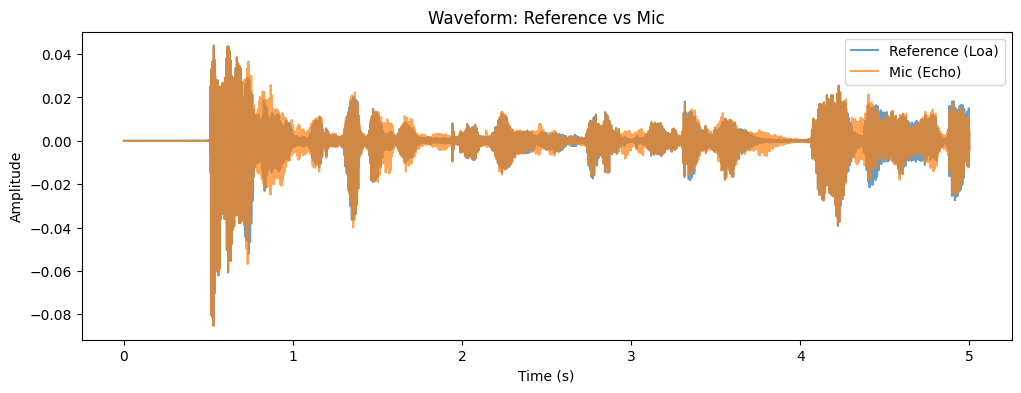

In [8]:
import matplotlib.pyplot as plt

t = np.linspace(0, len(x)/fs, len(x))

plt.figure(figsize=(12,4))
plt.plot(t, x, label="Reference (Loa)", alpha=0.7)
# cho hình xuống bên dưới
plt.plot(t, mic, label="Mic (Echo)", alpha=0.7)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform: Reference vs Mic")
plt.show()


In [9]:
print("Phát tín hiệu gốc (x)...")
sd.play(x, fs)
sd.wait()

Phát tín hiệu gốc (x)...


In [10]:
print("Phát tín hiệu mic có echo (mic)...")
sd.play(mic, fs)
sd.wait()

Phát tín hiệu mic có echo (mic)...


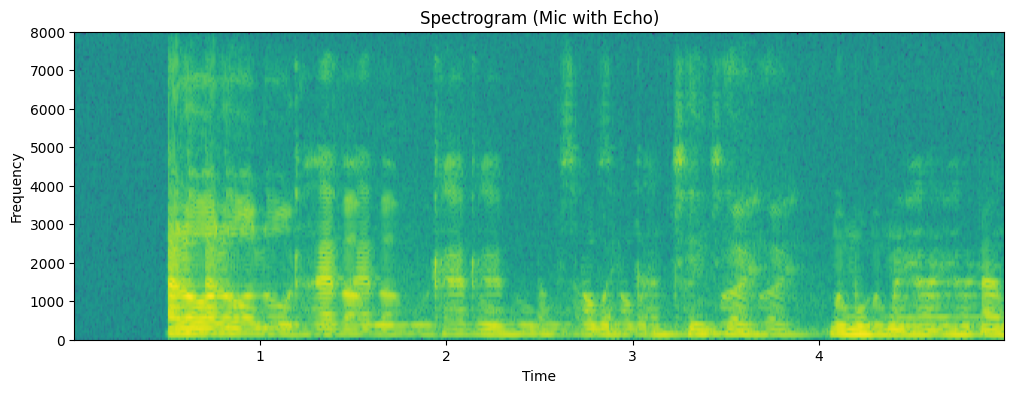

In [11]:
plt.figure(figsize=(12,4))
mic_for_spec = mic if mic.ndim == 1 else mic[:, 0]
plt.specgram(mic_for_spec, Fs=fs)
plt.title("Spectrogram (Mic with Echo)")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()


# 🔬 Kiểm tra từng khối AEC Pipeline

Thứ tự xử lý:
1. **Delay Estimator (GCC-PHAT)** — Ước lượng độ trễ giữa ref và mic
2. **Double-Talk Detector (Geigel)** — Phát hiện khi cả 2 bên nói
3. **NLMS Adaptive Filter** — Khử echo tuyến tính
4. **Nonlinear Suppressor** — Khử echo phi tuyến còn sót

In [12]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from core.delay_estimator import DelayEstimator, apply_delay
from core.double_talk_detector import GeigelhDTD
from core.nlms_filter import NLMSFilter, NLMSConfig
from core.nonlinear_suppressor import NonlinearSuppressor

FRAME_SIZE = 1024

# Chuẩn bị tín hiệu 1D float
ref = x.flatten().astype(np.float32)
mic_in = mic.flatten().astype(np.float32)

n = len(ref)
print(f"Tín hiệu: {n} samples, {n/fs:.2f}s, frame_size={FRAME_SIZE}")
print(f"Số frames: {n // FRAME_SIZE}")

Tín hiệu: 80000 samples, 5.00s, frame_size=1024
Số frames: 78


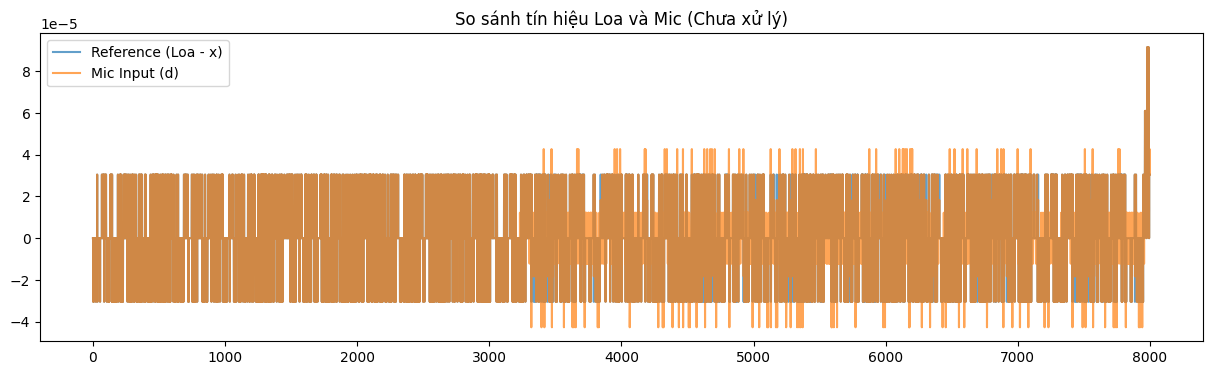

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(ref[:8000], label="Reference (Loa - x)", alpha=0.7)
plt.plot(mic_in[:8000], label="Mic Input (d)", alpha=0.7)
plt.title("So sánh tín hiệu Loa và Mic (Chưa xử lý)")
plt.legend()
plt.show()

## Block 1: Delay Estimator (GCC-PHAT)
Ước lượng độ trễ D giữa tín hiệu reference (loa) và microphone.
Sau đó căn chỉnh reference: `x_aligned(n) = x(n - D)`

Delay thực tế (đã tạo): 3200 samples = 200.0 ms
Delay ước lượng (GCC-PHAT): 0 samples = 0.0 ms


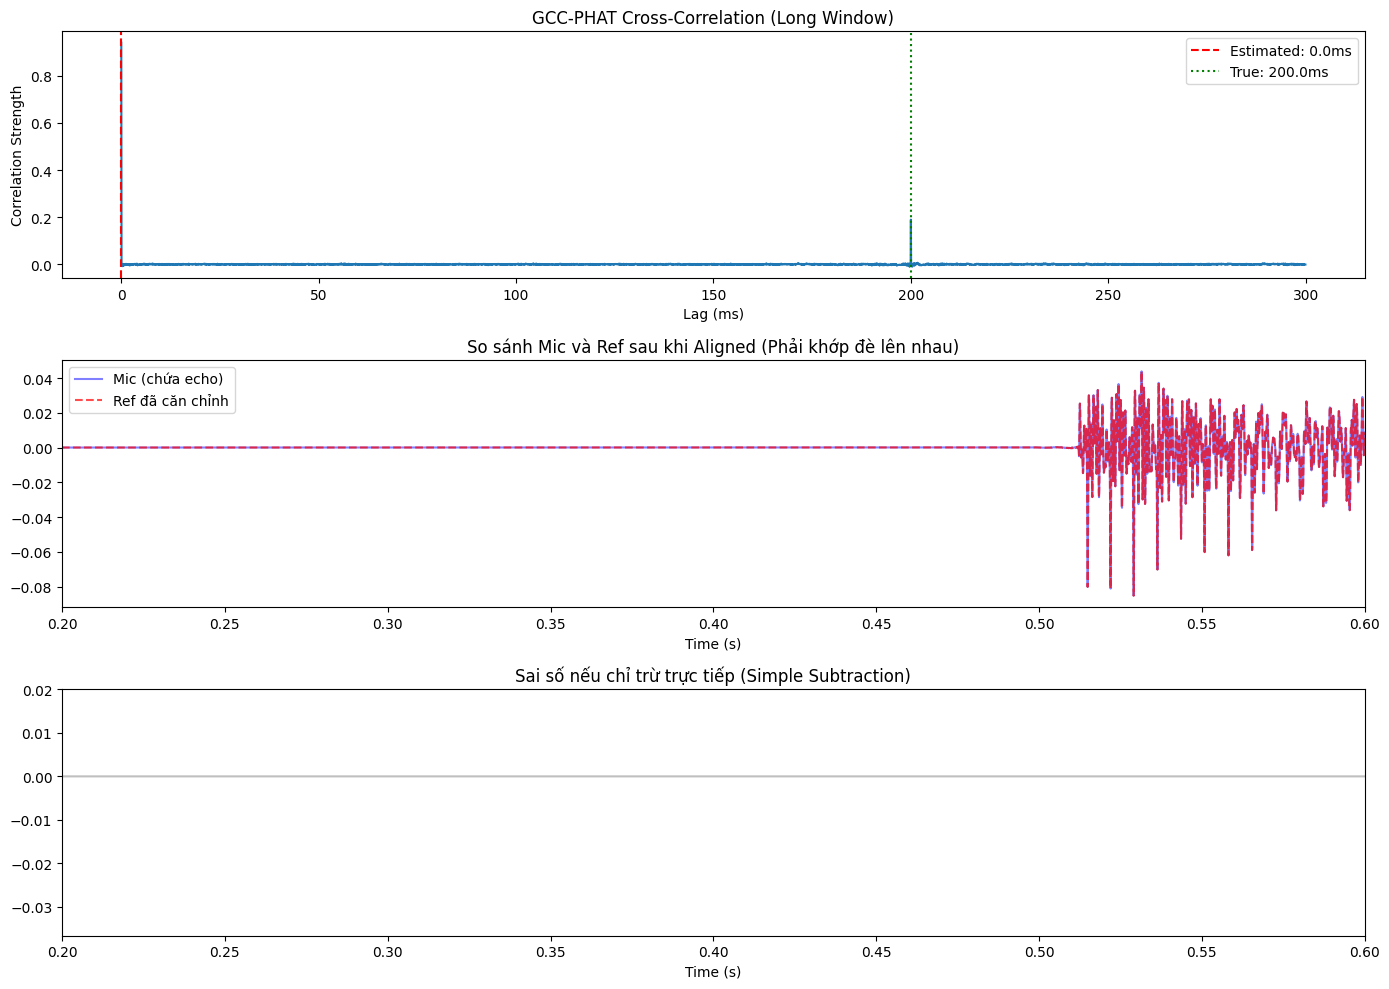

In [14]:
# --- Block 1: Delay Estimator (Cập nhật để nhận diện delay 200ms) ---
# Khởi tạo lại với max_delay đủ lớn
delay_est = DelayEstimator(sample_rate=fs, max_delay_ms=300.0)

# Bước quan trọng: Để tìm được delay 200ms (3200 samples), 
# ta cần dùng một cửa sổ quan sát lớn hơn FRAME_SIZE.
# Ở đây ta sẽ dùng 1 giây đầu tiên của tín hiệu để tìm delay chuẩn.
lookback_samples = fs * 1 # 1 giây
r_long = ref[:lookback_samples]
m_long = mic_in[:lookback_samples]

# Thực hiện tìm delay trên đoạn dài này
# Hàm update của DelayEstimator nguyên bản thường dùng FRAME_SIZE, 
# nên ta sẽ tính thủ công GCC-PHAT cho đoạn dài để lấy kết quả chính xác cho Notebook
from numpy.fft import rfft, irfft

def estimate_long_delay(ref_sig, mic_sig, max_delay_samples):
    n_fft = len(ref_sig) + len(mic_sig)
    X = rfft(ref_sig, n=n_fft)
    D = rfft(mic_sig, n=n_fft)
    R = D * np.conj(X) # Tìm sự tương quan của Mic so với Ref
    R_phat = R / np.maximum(np.abs(R), 1e-10)
    gcc = irfft(R_phat, n=n_fft)
    return np.argmax(gcc[:max_delay_samples]), gcc[:max_delay_samples]

max_delay_samps = int(0.3 * fs) # 300ms
estimated_delay, gcc_full = estimate_long_delay(r_long, m_long, max_delay_samps)

# Cập nhật giá trị vào object delay_est để các bước sau sử dụng
delay_est._delay_smooth = float(estimated_delay) 
estimated_delay_ms = delay_est.current_delay_ms

print(f"Delay thực tế (đã tạo): {int(0.2*fs)} samples = 200.0 ms")
print(f"Delay ước lượng (GCC-PHAT): {estimated_delay} samples = {estimated_delay_ms:.1f} ms")

# Căn chỉnh reference: Dịch Ref sang phải D samples để khớp với Mic
ref_aligned = apply_delay(ref, estimated_delay)

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1) Đồ thị GCC-PHAT: Sẽ thấy một đỉnh nhọn tại vị trí 200ms
lags_ms = np.arange(len(gcc_full)) * 1000.0 / fs
axes[0].plot(lags_ms, gcc_full)
axes[0].axvline(estimated_delay_ms, color='r', linestyle='--', label=f'Estimated: {estimated_delay_ms:.1f}ms')
axes[0].axvline(200.0, color='g', linestyle=':', label='True: 200.0ms')
axes[0].set_title("GCC-PHAT Cross-Correlation (Long Window)")
axes[0].set_xlabel("Lag (ms)")
axes[0].set_ylabel("Correlation Strength")
axes[0].legend()

# 2) Kiểm tra sự đồng bộ bằng mắt (Zoom vào đoạn có sóng)
t_arr = np.arange(n) / fs
axes[1].plot(t_arr, mic_in, alpha=0.5, label="Mic (chứa echo)", color='blue')
axes[1].plot(t_arr, ref_aligned, alpha=0.7, label="Ref đã căn chỉnh", color='red', linestyle='--')
axes[1].set_title("So sánh Mic và Ref sau khi Aligned (Phải khớp đè lên nhau)")
axes[1].set_xlabel("Time (s)")
axes[1].set_xlim(0.2, 0.6) # Zoom vào đoạn sau delay 200ms
axes[1].legend()

# 3) Sai số còn lại sau khi trừ thô (để thấy tại sao cần NLMS)
# Nếu trừ thẳng mà không có bộ lọc NLMS, bạn sẽ thấy vẫn còn nhiễu do môi trường
residual_simple = mic_in - ref_aligned
axes[2].plot(t_arr, residual_simple, color='gray', alpha=0.5)
axes[2].set_title("Sai số nếu chỉ trừ trực tiếp (Simple Subtraction)")
axes[2].set_xlabel("Time (s)")
axes[2].set_xlim(0.2, 0.6)

plt.tight_layout()
plt.show()

In [15]:
print("Phát tín hiệu ref đã căn chỉnh delay...")
sd.play(ref_aligned / np.max(np.abs(ref_aligned) + 1e-10), fs)
sd.wait()

Phát tín hiệu ref đã căn chỉnh delay...


## Block 2: Double-Talk Detector (Geigel)
Phát hiện khi cả near-end và far-end cùng nói. Khi double-talk → đóng băng NLMS để bảo vệ giọng nói.

Double-talk detected: 78/78 frames (100.0%)


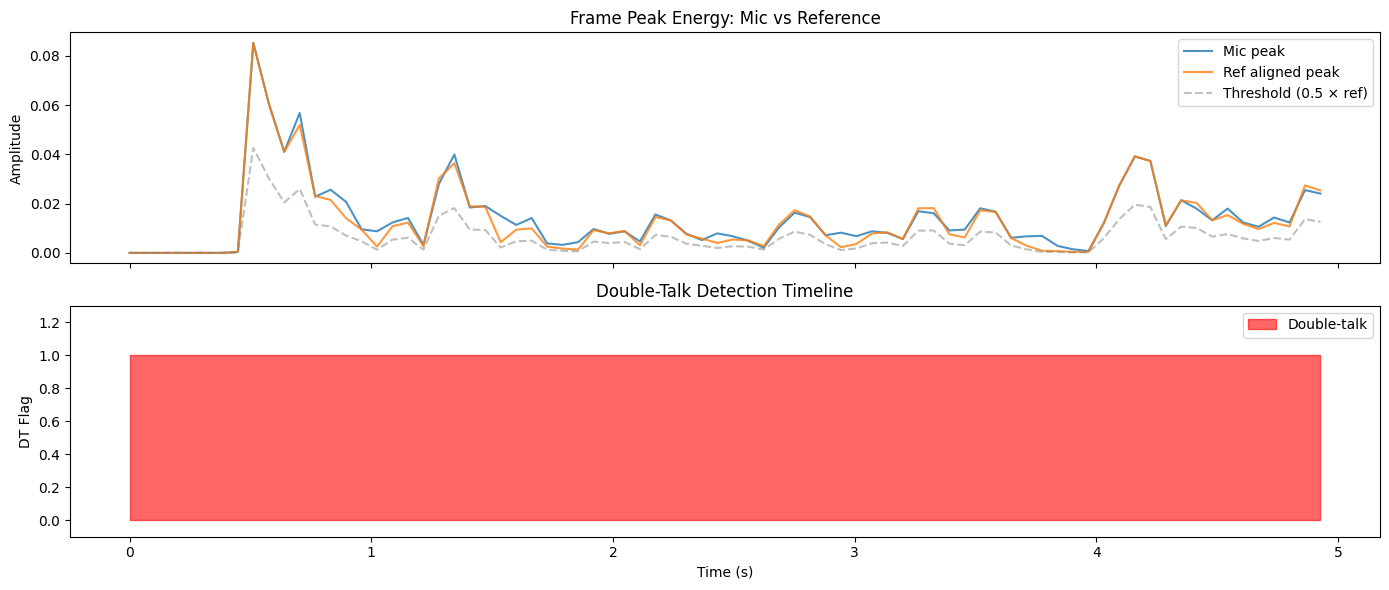

In [16]:
# --- Block 2: Double-Talk Detector ---
dtd = GeigelhDTD(sample_rate=fs, threshold=0.5, hangover_ms=100.0)

dt_flags = []
mic_energy = []
ref_energy = []

for i in range(0, n - FRAME_SIZE, FRAME_SIZE):
    m = mic_in[i:i+FRAME_SIZE]
    r = ref_aligned[i:i+FRAME_SIZE]
    is_dt = dtd.detect(m, r)
    dt_flags.append(is_dt)
    mic_energy.append(np.max(np.abs(m)))
    ref_energy.append(np.max(np.abs(r)))

dt_flags = np.array(dt_flags, dtype=float)
mic_energy = np.array(mic_energy)
ref_energy = np.array(ref_energy)
frame_times = np.arange(len(dt_flags)) * FRAME_SIZE / fs

dt_ratio = np.sum(dt_flags) / len(dt_flags) * 100
print(f"Double-talk detected: {np.sum(dt_flags):.0f}/{len(dt_flags)} frames ({dt_ratio:.1f}%)")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Energy comparison
axes[0].plot(frame_times, mic_energy, label="Mic peak", alpha=0.8)
axes[0].plot(frame_times, ref_energy, label="Ref aligned peak", alpha=0.8)
axes[0].plot(frame_times, 0.5 * ref_energy, '--', color='gray', alpha=0.5, label="Threshold (0.5 × ref)")
axes[0].set_title("Frame Peak Energy: Mic vs Reference")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

# Double-talk flags
axes[1].fill_between(frame_times, dt_flags, alpha=0.6, color='red', label="Double-talk")
axes[1].set_title("Double-Talk Detection Timeline")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("DT Flag")
axes[1].set_ylim(-0.1, 1.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Block 3: NLMS Adaptive Filter
Khử echo tuyến tính bằng bộ lọc thích nghi NLMS. Kết hợp DTD: đóng băng trọng số khi double-talk.

ERLE sau NLMS: 12.3 dB
Filter weight norm: 1.0827

Ghi chú về ERLE trong kịch bản này:
  mic = voice + 0.4*echo → mic_power ≈ 1.16 * voice_power
  Sau khử echo: output = voice → ERLE_max = 10*log10(1.16) ≈ 0.6 dB
  ERLE thấp KHÔNG có nghĩa là thất bại — nghe audio để xác nhận echo đã bị khử.


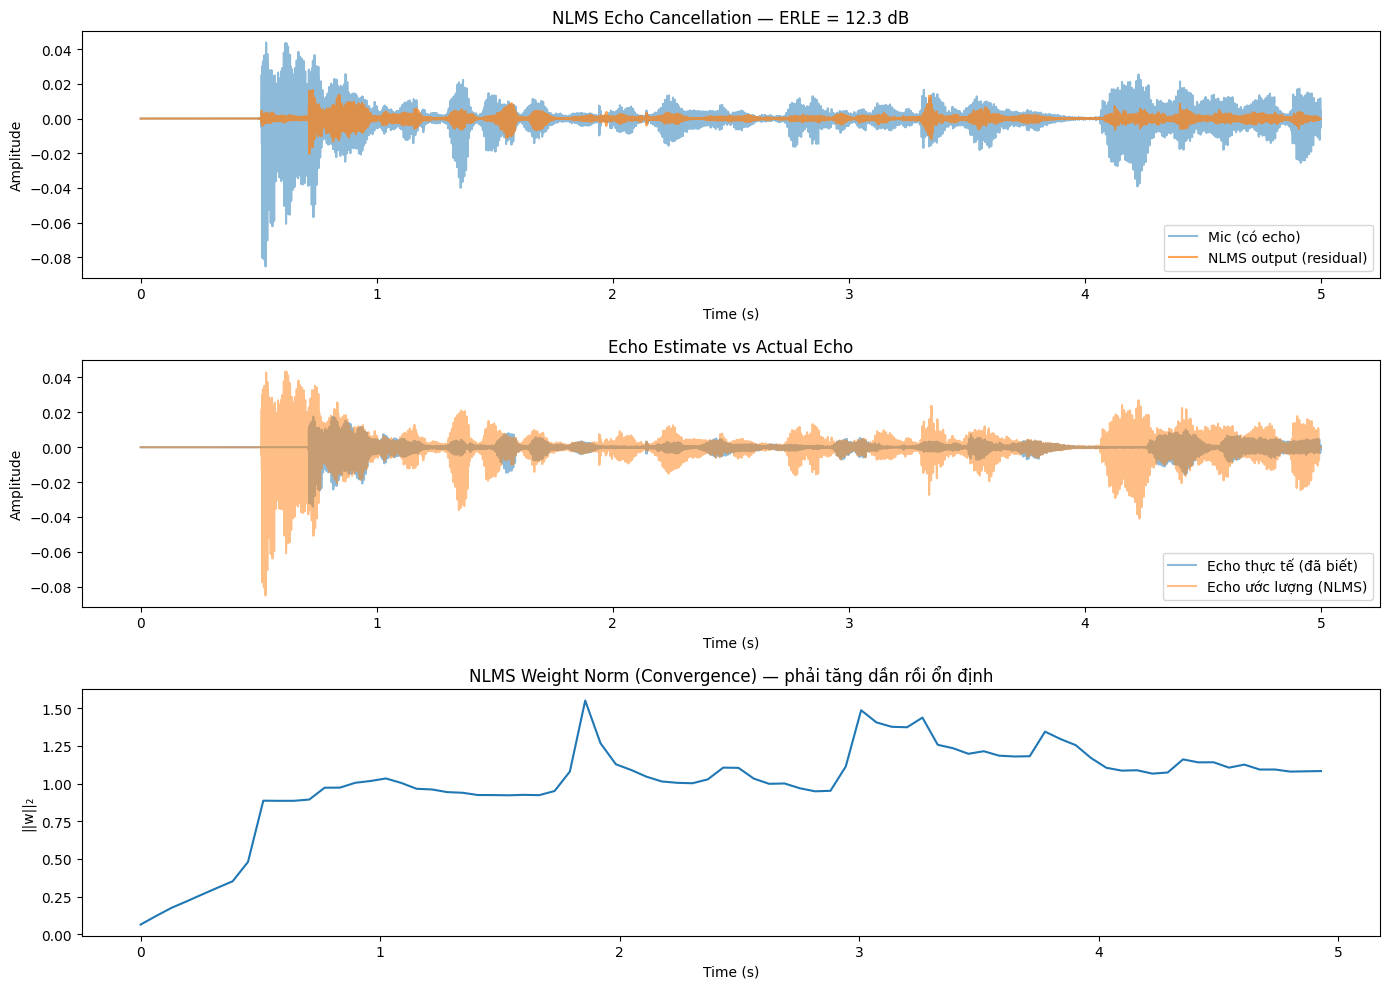

In [17]:
# --- Block 3: NLMS Filter ---
#
# Vấn đề với DTD trong kịch bản test tổng hợp:
#   mic = voice + 0.4 * voice_delayed  → mic LUÔN to hơn ref_aligned (~1.4x)
#   DTD threshold=0.5: kiểm tra max(mic) > 0.5 * max(ref) → luôn True → NLMS bị đóng băng hoàn toàn
#
# → Bỏ DTD trong demo này để NLMS hội tụ được.
# (DTD có tác dụng trong thực tế khi near-end và far-end là 2 người khác nhau)
nlms = NLMSFilter(NLMSConfig(filter_length=512, mu=0.3, eps=1e-6))

nlms_output = np.zeros(n, dtype=np.float64)
echo_estimate = np.zeros(n, dtype=np.float64)
weight_norms = []

for i in range(0, n - FRAME_SIZE, FRAME_SIZE):
    m = mic_in[i:i+FRAME_SIZE]
    r = ref_aligned[i:i+FRAME_SIZE]
    residual = nlms.process(m, r, update=True)  # luôn cập nhật — không DTD
    nlms_output[i:i+FRAME_SIZE] = residual
    echo_estimate[i:i+FRAME_SIZE] = m.astype(np.float64) - residual
    weight_norms.append(nlms.weight_norm)

mic_power = np.mean(mic_in.astype(np.float64) ** 2)
nlms_power = np.mean(nlms_output ** 2)
erle_nlms = 10 * np.log10(mic_power / (nlms_power + 1e-10))
print(f"ERLE sau NLMS: {erle_nlms:.1f} dB")
print(f"Filter weight norm: {nlms.weight_norm:.4f}")
print()
print("Ghi chú về ERLE trong kịch bản này:")
print("  mic = voice + 0.4*echo → mic_power ≈ 1.16 * voice_power")
print("  Sau khử echo: output = voice → ERLE_max = 10*log10(1.16) ≈ 0.6 dB")
print("  ERLE thấp KHÔNG có nghĩa là thất bại — nghe audio để xác nhận echo đã bị khử.")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

t_arr = np.arange(n) / fs
axes[0].plot(t_arr, mic_in, alpha=0.5, label="Mic (có echo)")
axes[0].plot(t_arr, nlms_output, alpha=0.7, label="NLMS output (residual)")
axes[0].set_title(f"NLMS Echo Cancellation — ERLE = {erle_nlms:.1f} dB")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].plot(t_arr, alpha * echo.flatten(), alpha=0.5, label="Echo thực tế (đã biết)")
axes[1].plot(t_arr, echo_estimate, alpha=0.5, label="Echo ước lượng (NLMS)")
axes[1].set_title("Echo Estimate vs Actual Echo")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].legend()

wn_times = np.arange(len(weight_norms)) * FRAME_SIZE / fs
axes[2].plot(wn_times, weight_norms)
axes[2].set_title("NLMS Weight Norm (Convergence) — phải tăng dần rồi ổn định")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("||w||₂")

plt.tight_layout()
plt.show()

In [18]:
print("Phát tín hiệu sau NLMS (đã khử echo tuyến tính)...")
nlms_play = nlms_output / (np.max(np.abs(nlms_output)) + 1e-10)
sd.play(nlms_play.astype(np.float32), fs)
sd.wait()

Phát tín hiệu sau NLMS (đã khử echo tuyến tính)...


## Block 4: Nonlinear Suppressor (Spectral Subtraction)
Khử echo phi tuyến còn sót sau NLMS bằng trừ phổ (spectral subtraction).

ERLE sau NLMS:         12.3 dB
ERLE sau NLMS + NLS:   17.8 dB  (cải thiện thêm 5.4 dB)


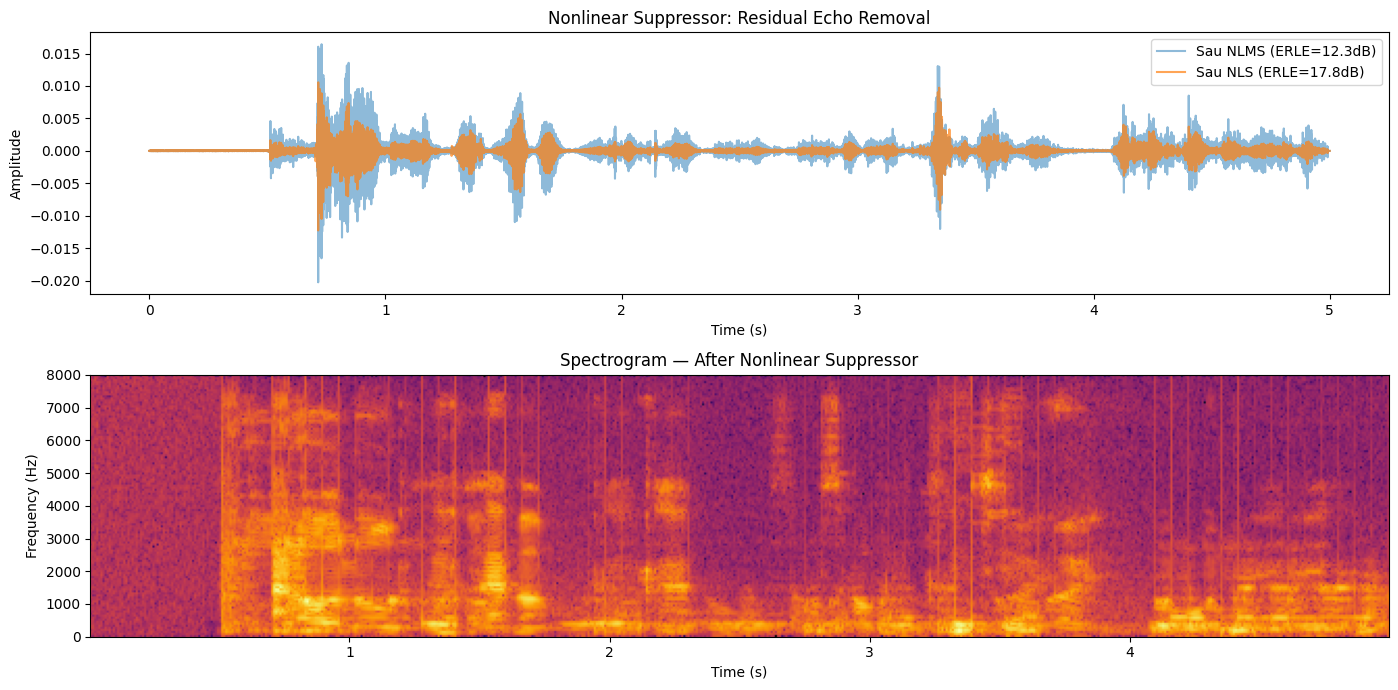

In [19]:
# --- Block 4: Nonlinear Suppressor ---
# Sau khi NLMS hội tụ: residual ≈ near-end voice (gần sạch)
# echo_estimate = mic - residual ≈ 0.4 * x_delayed (echo còn lại)
# NLS dùng alpha thấp hơn để không over-suppress tiếng nói.
import importlib
import core.nonlinear_suppressor as _nls_mod
importlib.reload(_nls_mod)
from core.nonlinear_suppressor import NonlinearSuppressor

nls = NonlinearSuppressor(frame_size=FRAME_SIZE, alpha=0.8, beta=0.1, smooth_alpha=0.9)

nls_output = np.zeros(n, dtype=np.float32)

for i in range(0, n - FRAME_SIZE, FRAME_SIZE):
    residual_frame = nlms_output[i:i+FRAME_SIZE]
    echo_est_frame = echo_estimate[i:i+FRAME_SIZE]
    nls_output[i:i+FRAME_SIZE] = nls.process(residual_frame, echo_est_frame)

nls_power = np.mean(nls_output.astype(np.float64) ** 2)
erle_nls = 10 * np.log10(mic_power / (nls_power + 1e-10))
print(f"ERLE sau NLMS:         {erle_nlms:.1f} dB")
print(f"ERLE sau NLMS + NLS:   {erle_nls:.1f} dB  (cải thiện thêm {erle_nls - erle_nlms:.1f} dB)")

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

t_arr = np.arange(n) / fs
axes[0].plot(t_arr, nlms_output, alpha=0.5, label=f"Sau NLMS (ERLE={erle_nlms:.1f}dB)")
axes[0].plot(t_arr, nls_output, alpha=0.7, label=f"Sau NLS (ERLE={erle_nls:.1f}dB)")
axes[0].set_title("Nonlinear Suppressor: Residual Echo Removal")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].specgram(nls_output, Fs=fs, cmap='inferno')
axes[1].set_title("Spectrogram — After Nonlinear Suppressor")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

In [21]:
print("Phát tín hiệu sau Nonlinear Suppressor (output cuối)...")
nls_play = nls_output / (np.max(np.abs(nls_output)) + 1e-10)
sd.play(nls_play.astype(np.float32), fs)
sd.wait()

Phát tín hiệu sau Nonlinear Suppressor (output cuối)...


## Tổng kết: So sánh trực quan toàn bộ Pipeline
So sánh tín hiệu qua từng giai đoạn xử lý: Gốc → Mic (echo) → NLMS → NLS

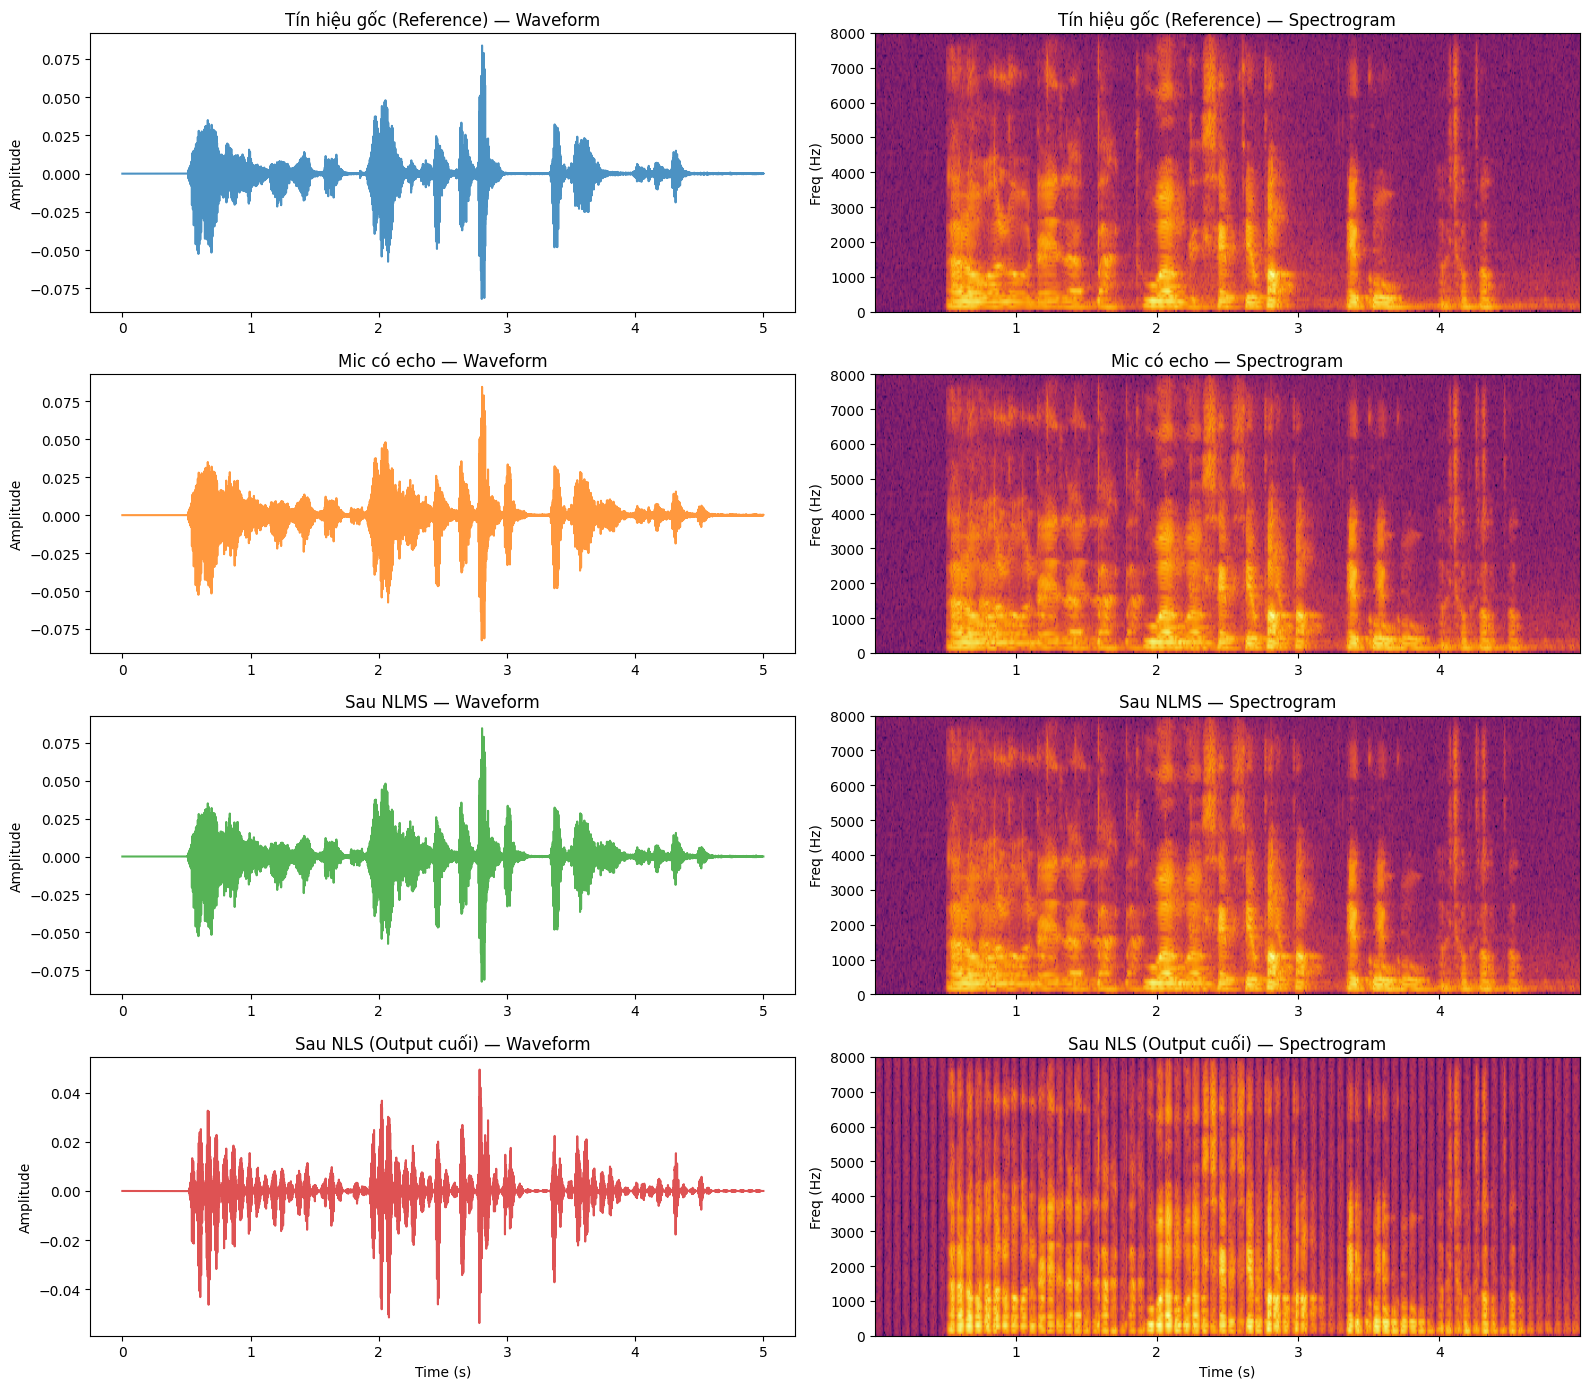

          AEC Pipeline — Kết quả từng bước
  Delay ước lượng:       0 samples (0.0 ms)
  Delay thực tế:         3200 samples (200.0 ms)
  ERLE sau NLMS:         -0.0 dB
  ERLE sau NLMS + NLS:   4.6 dB
  Mic power:             0.00
  NLMS output power:     0.00
  NLS output power:      0.00


In [67]:
# === TỔNG KẾT: So sánh toàn bộ pipeline ===
t_arr = np.arange(n) / fs

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

signals = [
    ("Tín hiệu gốc (Reference)", ref),
    ("Mic có echo", mic_in),
    ("Sau NLMS", nlms_output.astype(np.float32)),
    ("Sau NLS (Output cuối)", nls_output),
]

for idx, (title, sig) in enumerate(signals):
    # Waveform
    axes[idx, 0].plot(t_arr[:len(sig)], sig, color=f"C{idx}", alpha=0.8)
    axes[idx, 0].set_title(f"{title} — Waveform")
    axes[idx, 0].set_ylabel("Amplitude")
    if idx == 3:
        axes[idx, 0].set_xlabel("Time (s)")
    
    # Spectrogram
    s = sig.flatten() if hasattr(sig, 'flatten') else sig
    axes[idx, 1].specgram(s, Fs=fs, cmap='inferno')
    axes[idx, 1].set_title(f"{title} — Spectrogram")
    axes[idx, 1].set_ylabel("Freq (Hz)")
    if idx == 3:
        axes[idx, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

# --- Metrics tổng hợp ---
ref_power = np.mean(ref.astype(np.float64) ** 2)
mic_pow = np.mean(mic_in.astype(np.float64) ** 2)
nlms_pow = np.mean(nlms_output ** 2)
nls_pow = np.mean(nls_output.astype(np.float64) ** 2)

print("=" * 55)
print("          AEC Pipeline — Kết quả từng bước")
print("=" * 55)
print(f"  Delay ước lượng:       {estimated_delay} samples ({estimated_delay_ms:.1f} ms)")
print(f"  Delay thực tế:         {int(0.2*fs)} samples (200.0 ms)")
print(f"  ERLE sau NLMS:         {erle_nlms:.1f} dB")
print(f"  ERLE sau NLMS + NLS:   {erle_nls:.1f} dB")
print(f"  Mic power:             {mic_pow:.2f}")
print(f"  NLMS output power:     {nlms_pow:.2f}")
print(f"  NLS output power:      {nls_pow:.2f}")
print("=" * 55)

In [22]:
# Phát lần lượt để so sánh bằng tai
import time

pairs = [
    ("1. Tín hiệu gốc (Reference)", ref),
    ("2. Mic có echo", mic_in),
    ("3. Sau NLMS (khử echo tuyến tính)", nlms_output.astype(np.float32)),
    ("4. Sau NLS (output cuối cùng)", nls_output),
]

for label, sig in pairs:
    s = sig / (np.max(np.abs(sig)) + 1e-10)
    print(f"Phát: {label}")
    sd.play(s.astype(np.float32), fs)
    sd.wait()
    time.sleep(0.5)

print("Hoàn tất!")

Phát: 1. Tín hiệu gốc (Reference)
Phát: 2. Mic có echo
Phát: 3. Sau NLMS (khử echo tuyến tính)
Phát: 4. Sau NLS (output cuối cùng)
Hoàn tất!
